<a href="https://colab.research.google.com/github/proshenjitbarua06-dot/skill-morph/blob/main/skill_morph_class_11_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# ===================================================================
# ML Baseline for Diabetes Prediction
# Author: Grok (adapted from Skill Morph style)
# Dataset: Diabetes Prediction Dataset – Kaggle
# Classifiers: Support Vector Machine (SVM) & Gaussian Naive Bayes
# ===================================================================

# 1. Setup & Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_curve, roc_auc_score, precision_score,
                             recall_score, f1_score, accuracy_score)
import warnings
warnings.filterwarnings('ignore')

# 2. Load Dataset
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/Dataset/diabetes_prediction_dataset.csv')
print("Dataset Shape:", df.shape)
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset Shape: (100000, 9)


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [3]:
# 3. Data Preprocessing
# Check missing values
print("Missing values:\n", df.isnull().sum())

# Encode categorical features
categorical_cols = ['gender', 'smoking_history']
for col in categorical_cols:
    df[col] = LabelEncoder().fit_transform(df[col])

# Define features and target
X = df.drop(columns=['diabetes'])
y = df['diabetes']

print("Features:", X.columns.tolist())

Missing values:
 gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64
Features: ['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'HbA1c_level', 'blood_glucose_level']


In [4]:
# 4. Train-Test Split & Scaling
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f'Train: {X_train.shape} | Test: {X_test.shape}')

Train: (80000, 8) | Test: (20000, 8)


In [5]:
# 5. Model Training

# SVM (RBF Kernel)
svm_model = SVC(kernel='rbf', probability=True, random_state=42)
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)
y_prob_svm = svm_model.predict_proba(X_test)[:, 1]

# Gaussian Naive Bayes
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)
y_prob_nb = nb_model.predict_proba(X_test)[:, 1]

print("Models trained successfully!")

Models trained successfully!


In [6]:
# 6. Model Evaluation
print("="*60)
print("SVM Classification Report:")
print(classification_report(y_test, y_pred_svm))
print("="*60)
print("Naive Bayes Classification Report:")
print(classification_report(y_test, y_pred_nb))

SVM Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98     18300
           1       0.97      0.60      0.74      1700

    accuracy                           0.96     20000
   macro avg       0.97      0.80      0.86     20000
weighted avg       0.96      0.96      0.96     20000

Naive Bayes Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.93      0.95     18300
           1       0.46      0.66      0.54      1700

    accuracy                           0.90     20000
   macro avg       0.71      0.79      0.74     20000
weighted avg       0.92      0.90      0.91     20000



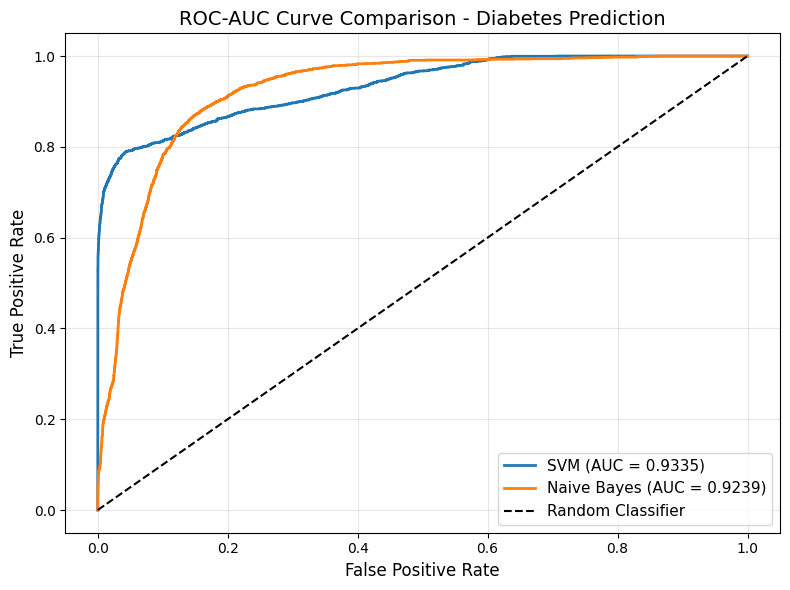

In [7]:
# 7. ROC-AUC Curve
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)
fpr_nb, tpr_nb, _ = roc_curve(y_test, y_prob_nb)
auc_svm = roc_auc_score(y_test, y_prob_svm)
auc_nb = roc_auc_score(y_test, y_prob_nb)

plt.figure(figsize=(8, 6))
plt.plot(fpr_svm, tpr_svm, label=f'SVM (AUC = {auc_svm:.4f})', linewidth=2)
plt.plot(fpr_nb, tpr_nb, label=f'Naive Bayes (AUC = {auc_nb:.4f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC-AUC Curve Comparison - Diabetes Prediction', fontsize=14)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

In [8]:
# 8. Results Summary Table
results = pd.DataFrame({
    'Model': ['SVM (RBF)', 'Naive Bayes'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_nb)
    ],
    'Precision': [
        precision_score(y_test, y_pred_svm),
        precision_score(y_test, y_pred_nb)
    ],
    'Recall': [
        recall_score(y_test, y_pred_svm),
        recall_score(y_test, y_pred_nb)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_svm),
        f1_score(y_test, y_pred_nb)
    ],
    'ROC-AUC': [auc_svm, auc_nb]
})

# Round to 4 decimal places
results.iloc[:, 1:] = results.iloc[:, 1:].round(4)
results

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,SVM (RBF),0.9645,0.9723,0.5994,0.7416,0.9335
1,Naive Bayes,0.9046,0.4574,0.6594,0.5401,0.9239
